# Plots


In [61]:
.004**.5



0.06324555320336758

/tmp/ipykernel_4932/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


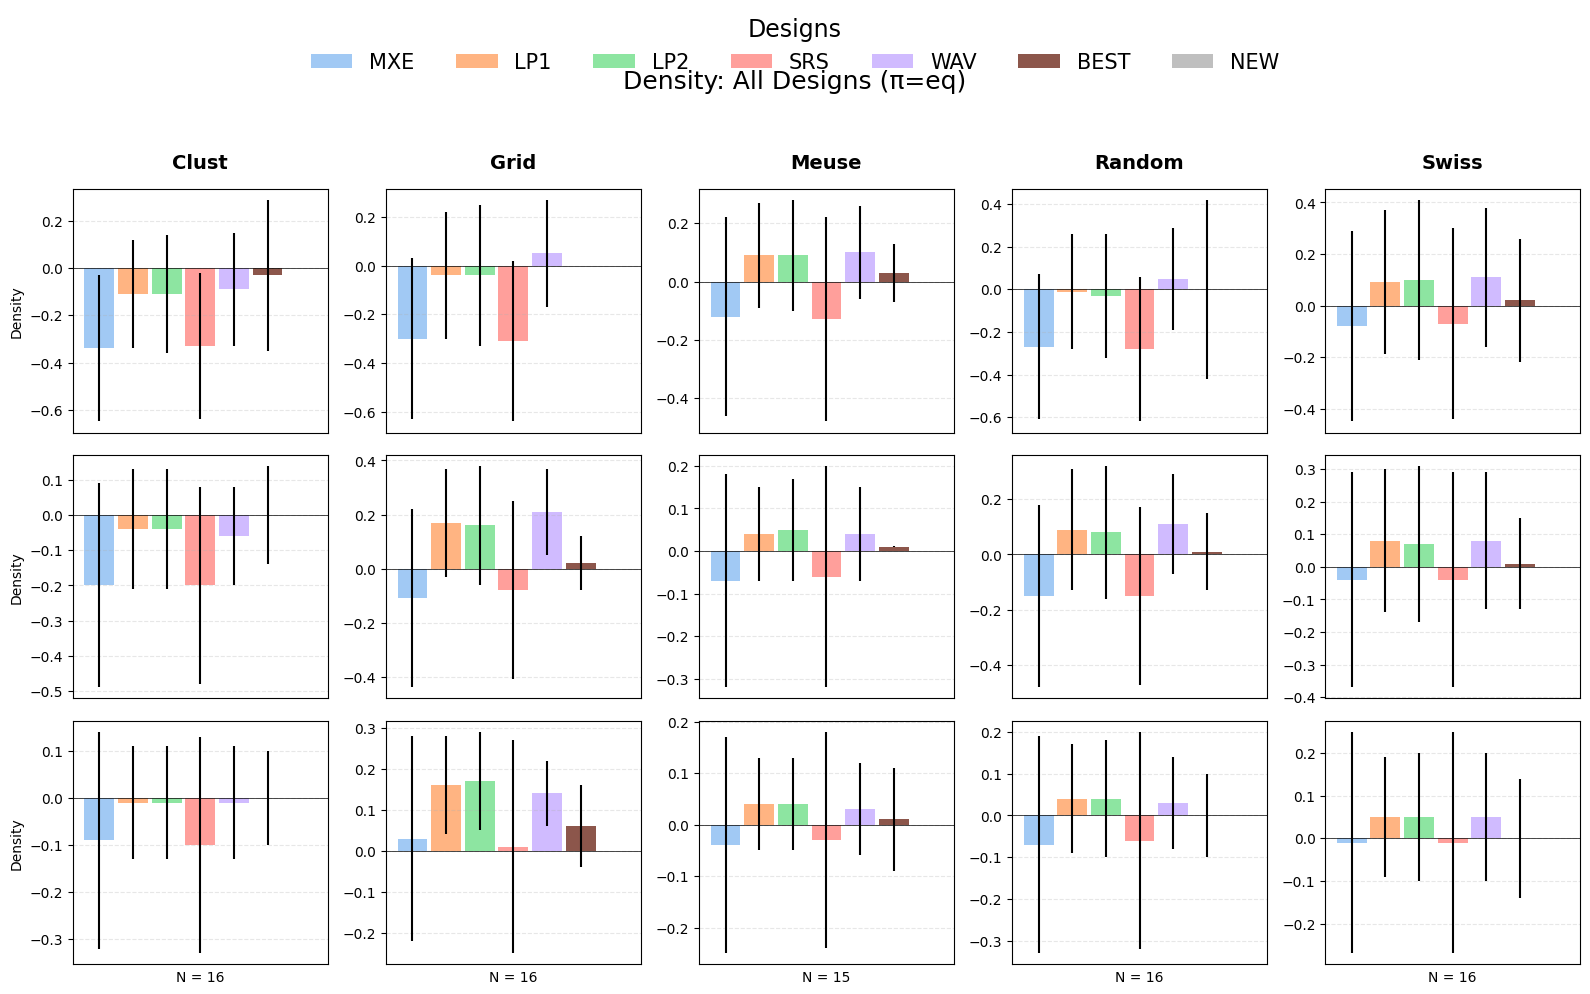

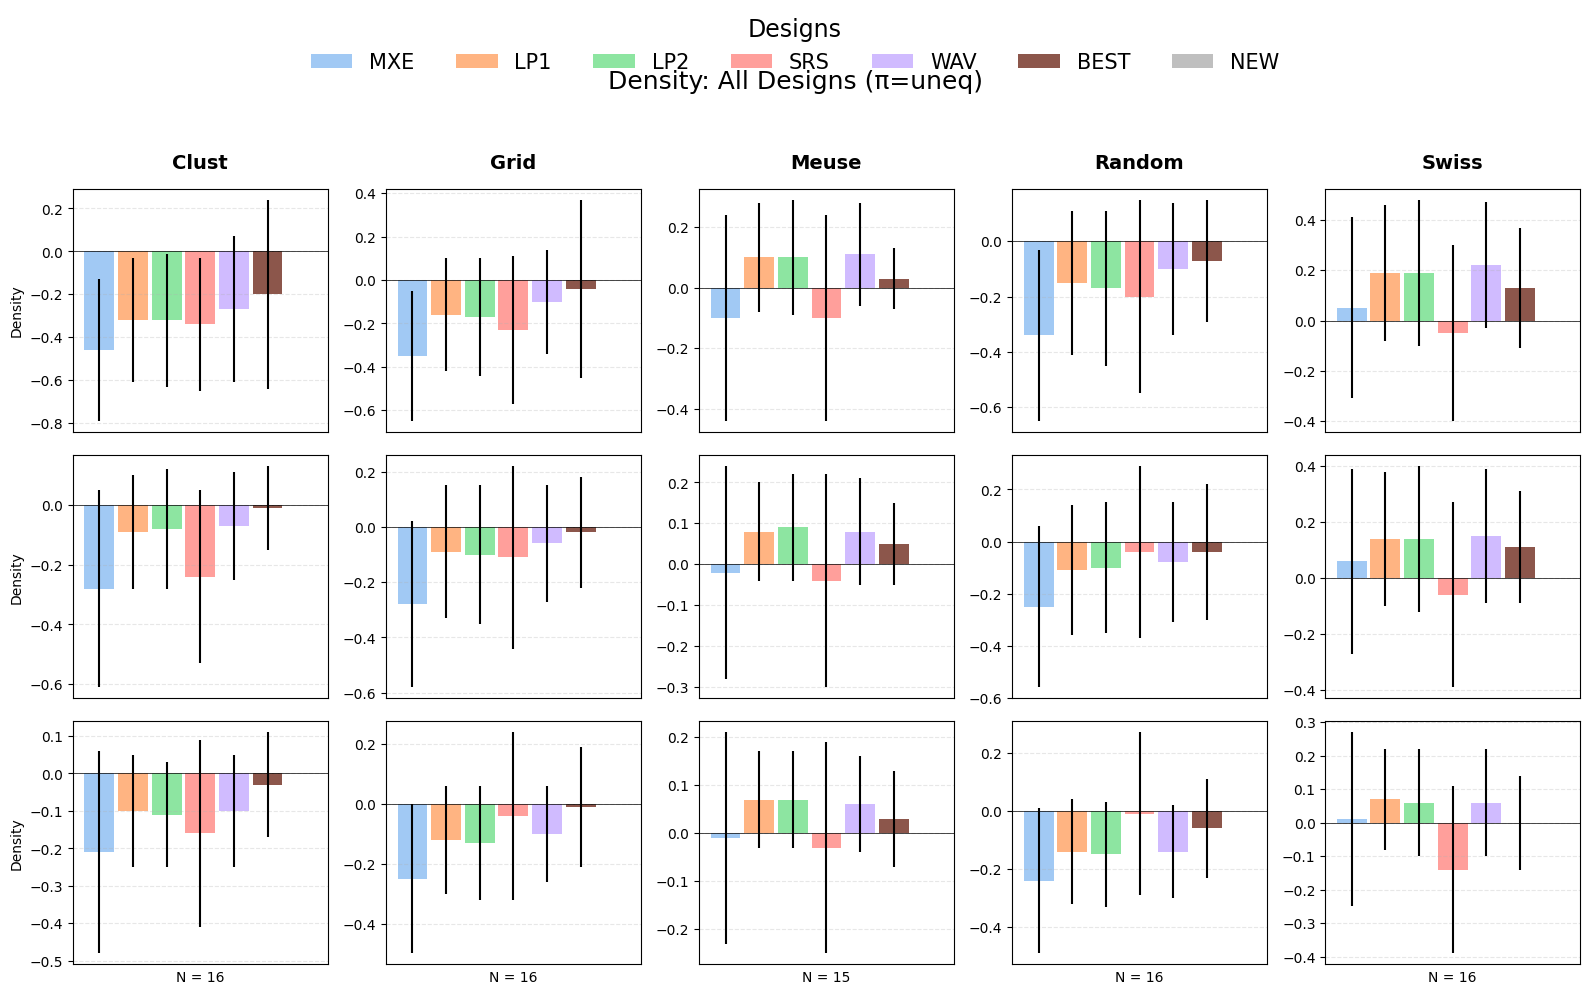

/tmp/ipykernel_4932/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


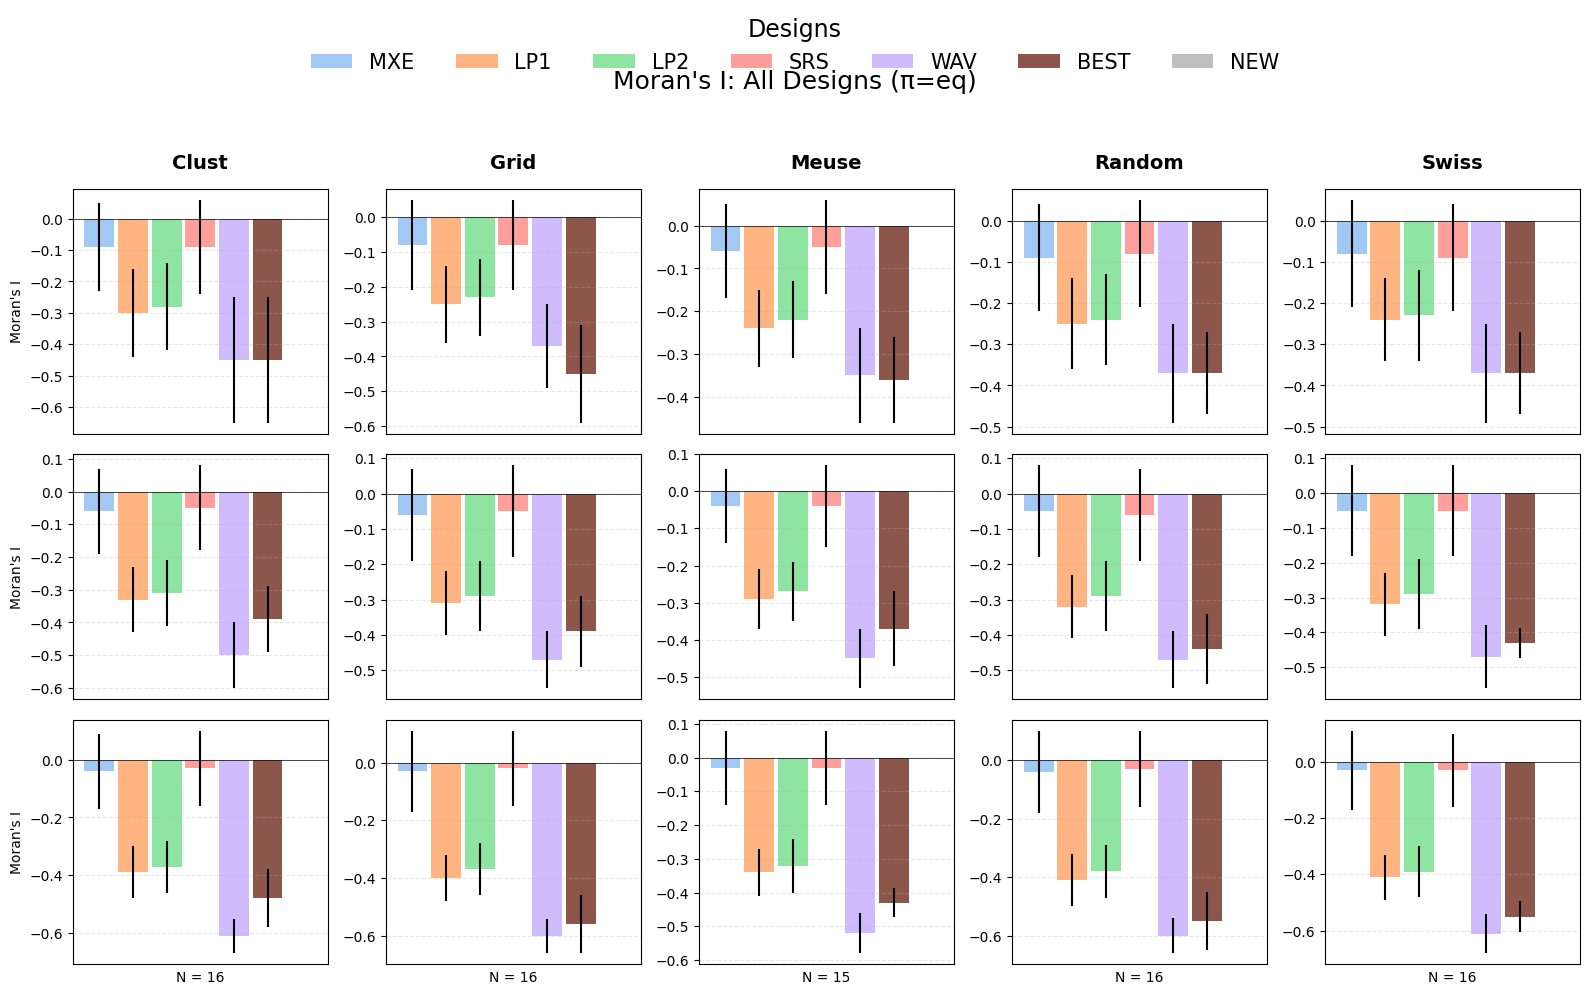

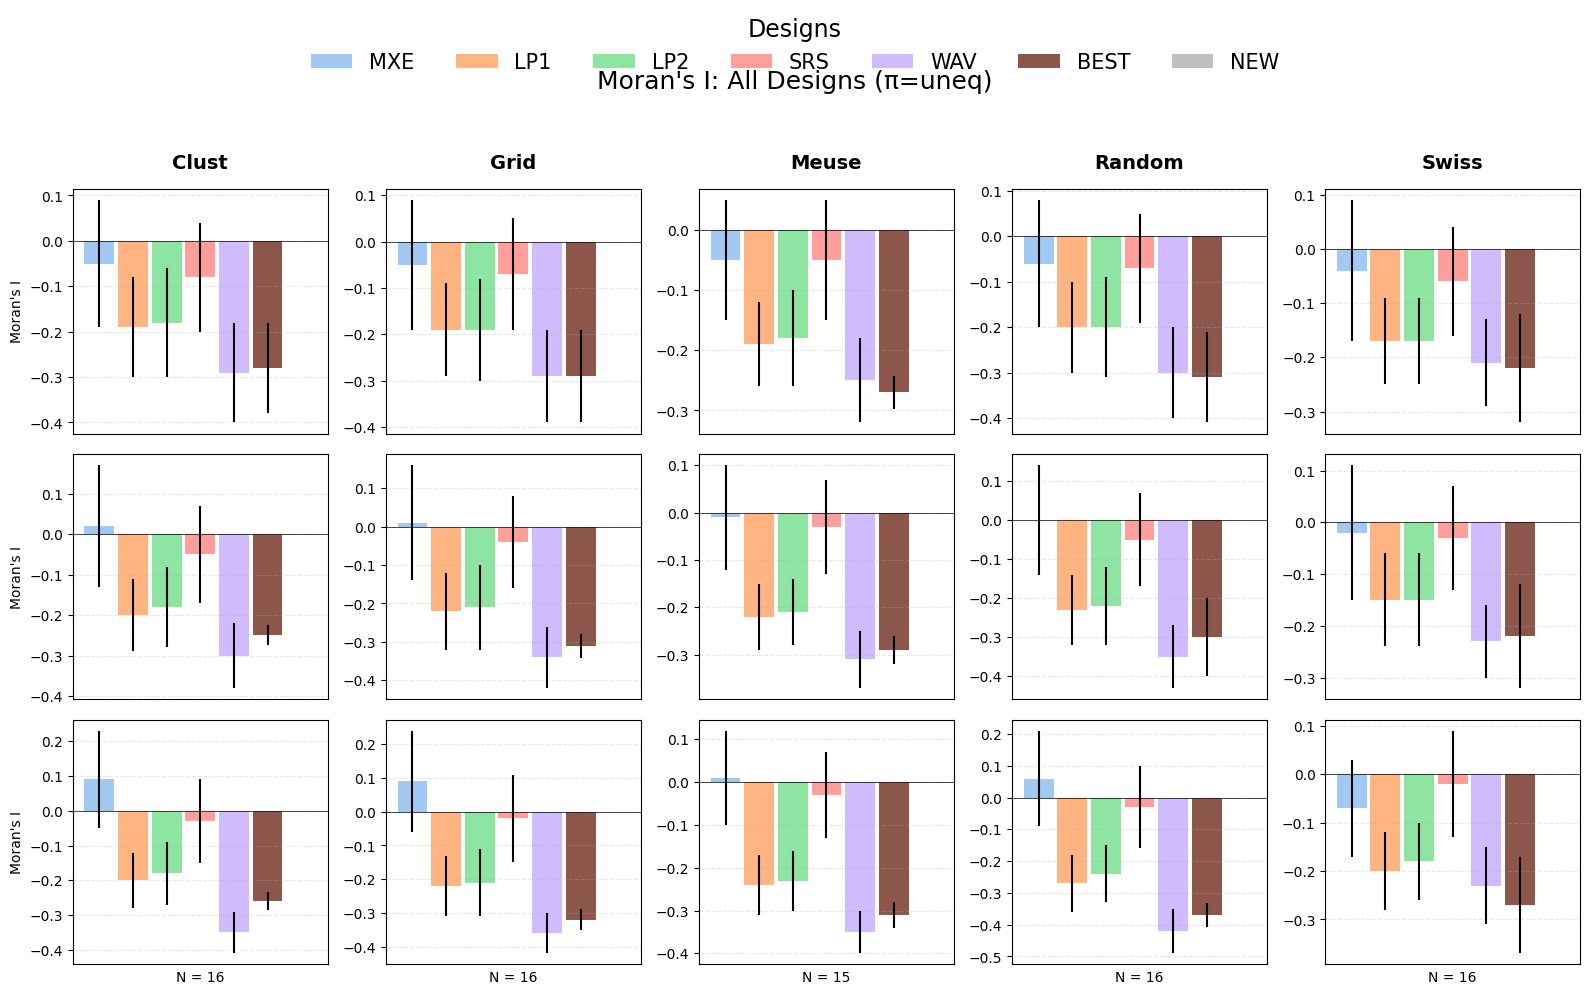

/tmp/ipykernel_4932/499598239.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


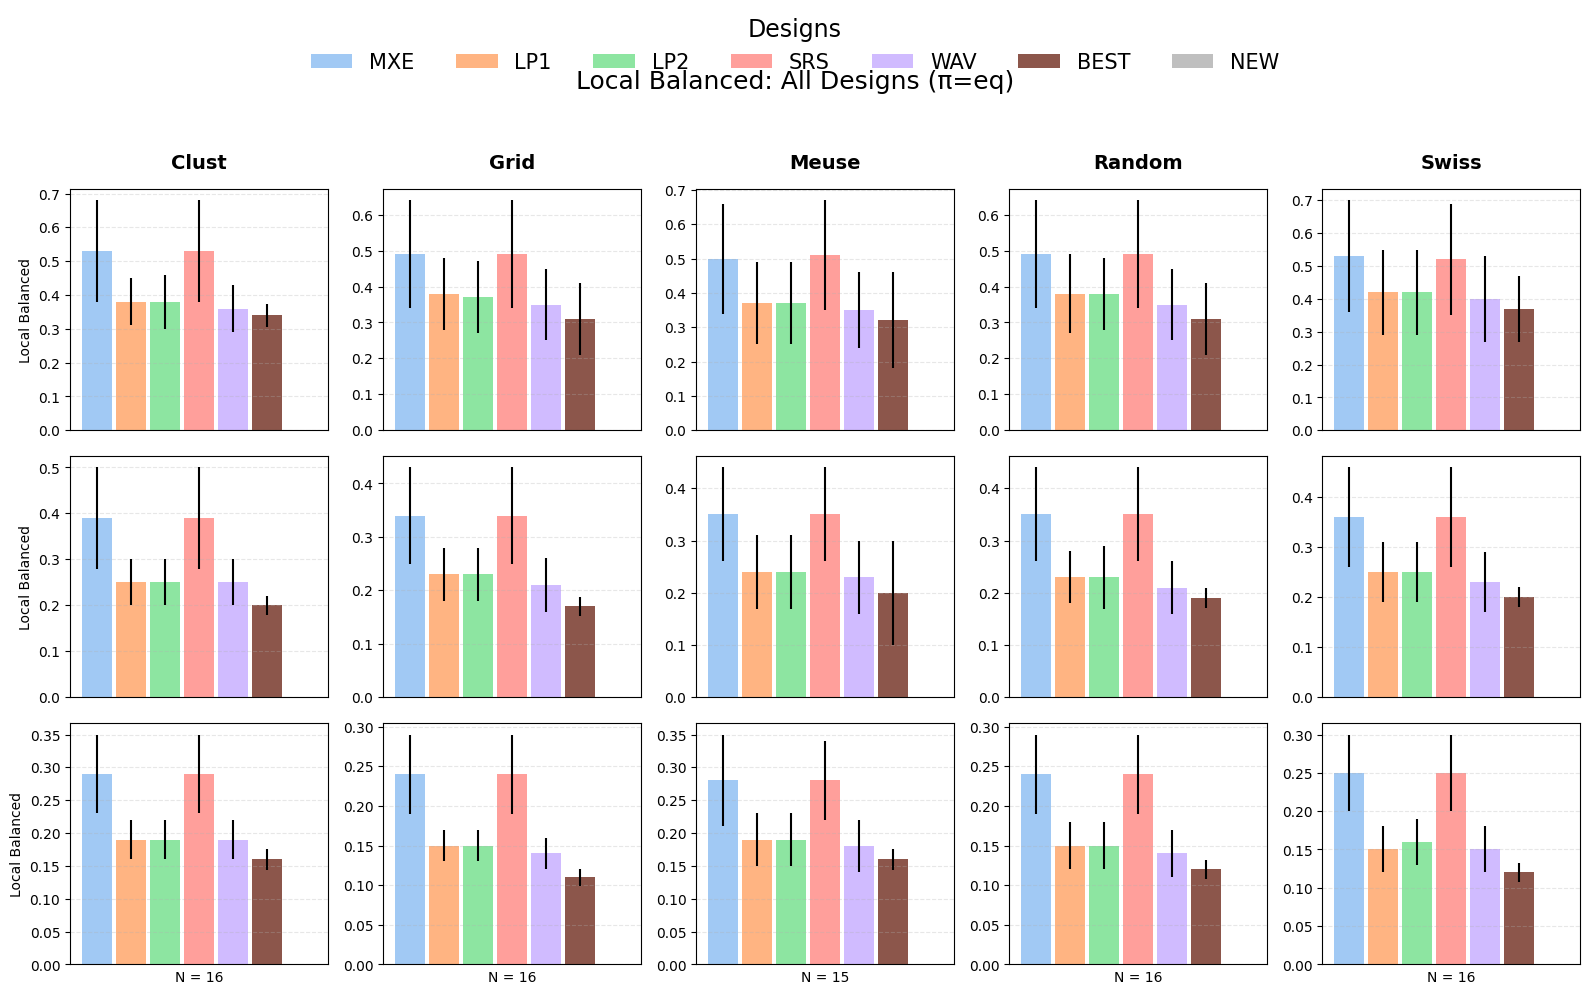

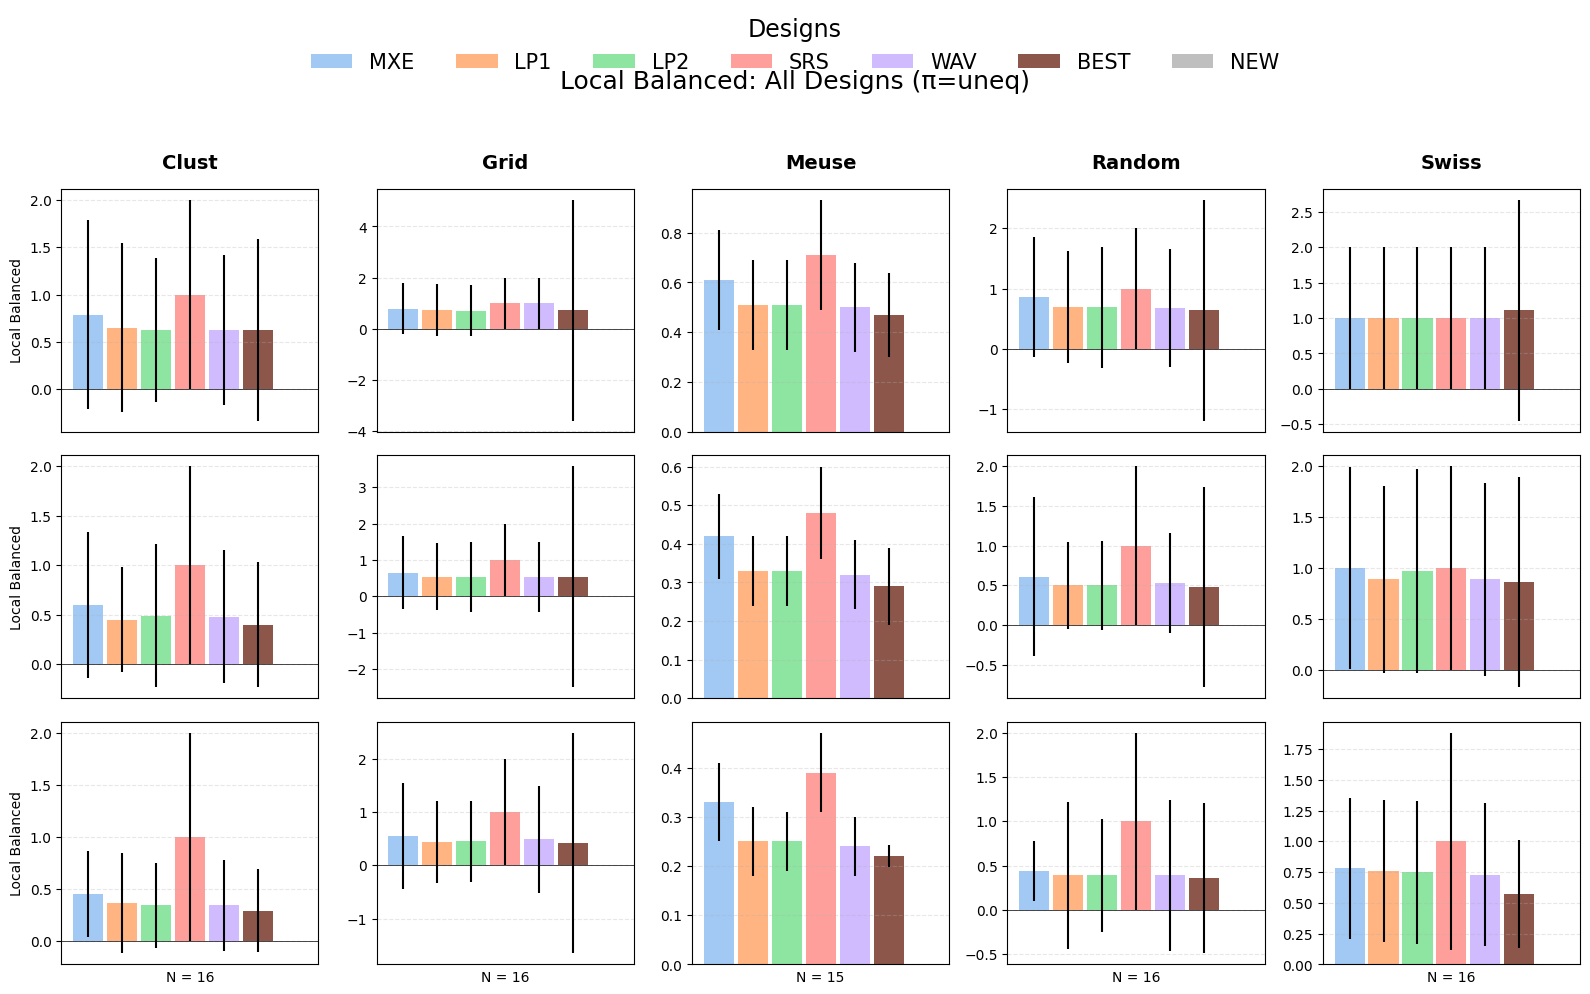

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_latex_table(path):
    """Parse a pandas-generated LaTeX table into a DataFrame."""
    with open(path, 'r') as f:
        lines = f.readlines()
    # Find header
    header_idx = next(i for i, line in enumerate(lines) if r"\toprule" in line) + 1
    cols = [c.strip() for c in lines[header_idx].strip().rstrip(r"\\").split('&')]
    data = []
    for line in lines[header_idx+2:]:
        if r"\bottomrule" in line:
            break
        parts = [p.strip() for p in line.strip().rstrip(r"\\").split('&')]
        if len(parts) == len(cols):
            data.append(parts)
    df = pd.DataFrame(data, columns=cols)
    return df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Paths to the accurate tables

table_paths = {
    'D': '/home/divar/projects/graphical-sampling/simulation_results/density_comparison_accurate.tex',
    'I': '/home/divar/projects/graphical-sampling/simulation_results/moran_comparison_accurate.tex',
    'L': '/home/divar/projects/graphical-sampling/simulation_results/local_balanced_comparison_accurate.tex'
}
labels = {'D': 'Density', 'I': "Moran's I", 'L': 'Local Balanced'}

# Abbrev map for designs
abbr = {'UPmaxentropy':'MXE','lpm1':'LP1','lpm2':'LP2','srs':'SRS','wave':'WAV'}

# Colors
colors = sns.color_palette("pastel", n_colors=len(abbr))
new_color = 'gray'
best_color = 'C5'

# Setup
populations = ['clust','grid','meuse','random','swiss']
sample_map = {
    'clust':  [4,8,16],
    'grid':   [4,8,16],
    'meuse':  [5,10,15],
    'random': [4,8,16],
    'swiss':  [4,8,16]
}
designs = ['UPmaxentropy','lpm1','lpm2','srs','wave']

# Generate plots
for crit, path in table_paths.items():
    df = parse_latex_table(path)
    # rename and convert
    df = df.rename(columns={'Popu':'Popu',r'$\pi$':'pi','N':'N','Desings':'Design',
                            f'{crit}_m':'mu',f'{crit}_{{std}}':'sd',
                            f'B {crit}_m':'bmu',f'B {crit}_{{std}}':'bsd'})
    df['mu'] = df['mu'].astype(float)
    df['sd'] = df['sd'].astype(float)
    df['bmu'] = df['bmu'].astype(float)
    df['bsd'] = df['bsd'].astype(float)
    df['pi'] = df['pi'].str.strip()
    df['Popu'] = df['Popu'].str.strip()
    df['N'] = df['N'].astype(int)

    for pi in ['eq','uneq']:
        fig, axs = plt.subplots(3,5,figsize=(16,10),sharey=False)
        fig.suptitle(f"{labels[crit]}: All Designs (π={pi})", fontsize=18, y=0.93)
        # column headers
        for col, pop in enumerate(populations):
            axs[0,col].set_title(pop.capitalize(), pad=15, fontsize=14, fontweight='bold')

        # subplots
        for col, pop in enumerate(populations):
            for row, N in enumerate(sample_map[pop]):
                ax = axs[row,col]
                sub = df[(df['Popu']==pop)&(df['pi']==pi)&(df['N']==N)]
                x = np.arange(len(designs)+2)
                width = 6.2/(len(designs)+2)
                # rivals
                for i,d in enumerate(designs):
                    r = sub[sub['Design']==d]
                    mu = min(1,r['mu'].iloc[0]) if not r.empty else 0.0
                    sd = min(1, r['sd'].iloc[0]) if not r.empty else 0.0
                    ax.bar(x[i], mu, width, yerr=sd, color=colors[i], label=abbr[d] if row==0 and col==0 else "")
                # best
                if not sub.empty:
                    bmu = sub['bmu'].iloc[0]
                    if sub['bsd'].iloc[0]>0:
                        bsd = sub['bsd'].iloc[0]
                    else:
                        bsd = min(.06, abs(bmu) * .1)  # default error if not provided
                else:
                    bmu = bsd = 0.0
                ax.bar(x[len(designs)], bmu, width, yerr=bsd, color=best_color, label='BEST' if row==0 and col==0 else "")
                # new
                ax.bar(x[-1], 0, width, color=new_color, alpha=0.5, label='NEW' if row==0 and col==0 else "")
                ax.axhline(0,color='black',lw=0.5)
                ax.set_xticks([])
                if col==0: ax.set_ylabel(labels[crit])
                if row==2: ax.set_xlabel(f"N = {N}")
                ax.grid(True,ls='--',alpha=0.3)

        # legend
        handles, labels_ = axs[0,0].get_legend_handles_labels()
        fig.legend(handles, labels_, title='Designs',
                   loc='upper center',bbox_to_anchor=(0.5,1.00),
                   ncol=len(handles),frameon=False,fontsize=15,title_fontsize=17)
        plt.tight_layout(rect=[0,0,1,0.90])
        plt.show()


# Store

In [1]:
import pandas as pd
import os

RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"

# 1) load your old summary
old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats.csv"))

# 2) load your new KMS evaluation
new = pd.read_csv(os.path.join(RESULTS_DIR, "evaluate_all.csv"))

# 3) aggregate KMS over its config‐combos
agg = {
    'exp_density':'mean','median_density':'mean','var_density':'mean','min_density':'mean','max_density':'mean',
    'exp_IB':'mean','median_IB':'mean','var_IB':'mean','min_IB':'mean','max_IB':'mean',
    'exp_LB':'mean','median_LB':'mean','var_LB':'mean','min_LB':'mean','max_LB':'mean',
}
new_summary = (
    new
    .groupby(['coord','prob','n'], as_index=False)
    .agg(agg)
)

# 4) label and rename columns to match old
new_summary['method'] = 'KMS'
new_summary = new_summary.rename(columns={
    'coord':'population',
    'prob':'ptype',
    'exp_density':'D_mu',
    'median_density':'D_me',
    'var_density':'D_sd',
    'min_density':'D_mn',
    'max_density':'D_mx',
    'exp_IB':'I_mu',
    'median_IB':'I_me',
    'var_IB':'I_sd',
    'min_IB':'I_mn',
    'max_IB':'I_mx',
    'exp_LB':'L_mu',
    'median_LB':'L_me',
    'var_LB':'L_sd',
    'min_LB':'L_mn',
    'max_LB':'L_mx',
})

new_summary = new_summary[
    ['population','ptype','n','method',
     'D_mu','D_me','D_sd','D_mn','D_mx',
     'I_mu','I_me','I_sd','I_mn','I_mx',
     'L_mu','L_me','L_sd','L_mn','L_mx']
]

# 5) concat old + new
combined = pd.concat([old, new_summary], ignore_index=True)

# 6) split “population” on underscore into population + ptype,
#    and map eq→EQ, uneq→UQ
mask = combined['population'].str.contains('_')
parts = combined.loc[mask, 'population'].str.rsplit('_', n=1, expand=True)
combined.loc[mask, 'population'] = parts[0]
combined.loc[mask, 'ptype']      = parts[1].map({'eq':'EQ', 'uneq':'UQ'})
combined[ 'ptype']      = combined[ 'ptype'].map({'eq':'EQ', 'uneq':'UQ'})

# 7) enforce method ordering and sort
method_order = ["SRS","UPM","LP1","LP2","WAV","KMS"]
combined['method'] = pd.Categorical(combined['method'],
                                    categories=method_order,
                                    ordered=True)

combined = combined.sort_values(
    by=['population','ptype','n','method'],
    ignore_index=True
)

# 8) write out and inspect
out_path = os.path.join(RESULTS_DIR, "summary_all_methods.csv")
combined.to_csv(out_path, index=False, float_format="%.2f")
print("✔ Wrote:", out_path)
print(combined.to_string())


FileNotFoundError: [Errno 2] No such file or directory: '/home/divar/projects/graphical-sampling/data_samples/results/summary_stats.csv'

In [ ]:
import pandas as pd
import os

RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"

# 1) load your old summary
old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats.csv"))

# 3) aggregate KMS over its config‐combos
agg = {
    'exp_density':'mean','median_density':'mean','var_density':'mean','min_density':'mean','max_density':'mean',
    'exp_IB':'mean','median_IB':'mean','var_IB':'mean','min_IB':'mean','max_IB':'mean',
    'exp_LB':'mean','median_LB':'mean','var_LB':'mean','min_LB':'mean','max_LB':'mean',
}
new_summary = (
    new
    .groupby(['coord','prob','n'], as_index=False)
    .agg(agg)
)

# 4) label and rename columns to match old
new_summary['method'] = 'KMS'
new_summary = new_summary.rename(columns={
    'coord':'population',
    'prob':'ptype',
    'exp_density':'D_mu',
    'median_density':'D_me',
    'var_density':'D_sd',
    'min_density':'D_mn',
    'max_density':'D_mx',
    'exp_IB':'I_mu',
    'median_IB':'I_me',
    'var_IB':'I_sd',
    'min_IB':'I_mn',
    'max_IB':'I_mx',
    'exp_LB':'L_mu',
    'median_LB':'L_me',
    'var_LB':'L_sd',
    'min_LB':'L_mn',
    'max_LB':'L_mx',
})

new_summary = new_summary[
    ['population','ptype','n','method',
     'D_mu','D_me','D_sd','D_mn','D_mx',
     'I_mu','I_me','I_sd','I_mn','I_mx',
     'L_mu','L_me','L_sd','L_mn','L_mx']
]

# 5) concat old + new
combined = pd.concat([old, new_summary], ignore_index=True)

# 6) split “population” on underscore into population + ptype,
#    and map eq→EQ, uneq→UQ
mask = combined['population'].str.contains('_')
parts = combined.loc[mask, 'population'].str.rsplit('_', n=1, expand=True)
combined.loc[mask, 'population'] = parts[0]
combined.loc[mask, 'ptype']      = parts[1].map({'eq':'EQ', 'uneq':'UQ'})
combined[ 'ptype']      = combined[ 'ptype'].map({'eq':'EQ', 'uneq':'UQ'})

# 7) enforce method ordering and sort
method_order = ["SRS","UPM","LP1","LP2","WAV","KMS"]
combined['method'] = pd.Categorical(combined['method'],
                                    categories=method_order,
                                    ordered=True)

combined = combined.sort_values(
    by=['population','ptype','n','method'],
    ignore_index=True
)

# 8) write out and inspect
out_path = os.path.join(RESULTS_DIR, "summary_all_methods.csv")
combined.to_csv(out_path, index=False, float_format="%.2f")
print("✔ Wrote:", out_path)
print(combined.to_string())


In [40]:
RESULTS_DIR = "/home/divar/projects/graphical-sampling/data_samples/results"


old = pd.read_csv(os.path.join(RESULTS_DIR, "summary_stats_new.csv"))
mask_old = old['method'] == 'wave'
sp_ind = 'D'
result = old.loc[mask_old,['population','method', 'ptype','n', f'{sp_ind}_mu', f'{sp_ind}_me', f'{sp_ind}_sd', f'{sp_ind}_mn', f'{sp_ind}_mx']]
display(result)

,population,method,ptype,n,D_mu,D_me,D_sd,D_mn,D_mx
4,clust,wave,eq,4,-0.09,-0.06,0.24,-0.77,0.41
9,clust,wave,eq,8,-0.06,-0.09,0.14,-0.50,0.36
14,clust,wave,eq,16,-0.01,-0.05,0.12,-0.34,0.27
19,clust,wave,uneq,4,-0.27,-0.32,0.34,-0.91,0.33
24,clust,wave,uneq,8,-0.07,-0.10,0.18,-0.82,0.33
29,clust,wave,uneq,16,-0.10,-0.11,0.15,-0.62,0.29
34,grid,wave,eq,4,0.05,0.10,0.22,-0.65,0.68
39,grid,wave,eq,8,0.21,0.22,0.16,-0.41,0.68
44,grid,wave,eq,16,0.14,0.15,0.08,-0.20,0.36
49,grid,wave,uneq,4,-0.10,-0.14,0.24,-0.76,0.57


In [3]:
# First, let's recreate the rivals' tables from the images provided manually to perform matching
# This data is directly extracted from the images provided by the user.
import pandas as pd
# Moran's I (I) data from rivals
rivals_I = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'I_mu': [-0.45, -0.50, -0.61, -0.29, -0.30, -0.35,
             -0.37, -0.47, -0.60, -0.29, -0.34, -0.36,
             -0.35, -0.45, -0.52, -0.25, -0.31, -0.35,
             -0.37, -0.47, -0.60, -0.30, -0.35, -0.42,
             -0.37, -0.47, -0.61, -0.21, -0.23, -0.23],
    'I_sd': [0.20, 0.10, 0.06, 0.11, 0.08, 0.06,
             0.12, 0.08, 0.06, 0.10, 0.08, 0.06,
             0.11, 0.08, 0.06, 0.07, 0.06, 0.05,
             0.12, 0.08, 0.06, 0.10, 0.08, 0.07,
             0.12, 0.09, 0.07, 0.08, 0.07, 0.08]
})

# Local Balanced (L) data from rivals
rivals_L = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'L_mu': [0.36, 0.25, 0.19, 0.63, 0.48, 0.34,
             0.35, 0.21, 0.14, 1.00, 0.53, 0.49,
             0.35, 0.23, 0.18, 0.50, 0.32, 0.24,
             0.35, 0.21, 0.14, 0.68, 0.53, 0.39,
             0.40, 0.23, 0.15, 1.15, 0.89, 0.73],
    'L_sd': [0.07, 0.05, 0.03, 0.79, 0.67, 0.44,
             0.10, 0.05, 0.02, 14.21, 0.96, 3.59,
             0.11, 0.07, 0.04, 0.18, 0.09, 0.06,
             0.10, 0.05, 0.03, 0.98, 0.63, 0.85,
             0.13, 0.06, 0.03, 1.45, 0.95, 0.58]
})

# Density (D) data from rivals
rivals_D = pd.DataFrame({
    'population': ['clust']*6 + ['grid']*6 + ['meuse']*6 + ['random']*6 + ['swiss']*6,
    'ptype': ['eq', 'eq', 'eq', 'uneq', 'uneq', 'uneq']*5,
    'n': [4, 8, 16]*10,
    'D_mu': [-0.09, -0.06, -0.01, -0.27, -0.07, -0.10,
             0.05, 0.21, 0.14, -0.10, -0.06, -0.10,
             0.10, 0.04, 0.03, 0.11, 0.08, 0.06,
             0.05, 0.11, 0.03, -0.10, -0.08, -0.14,
             0.11, 0.08, 0.05, 0.22, 0.15, 0.06],
    'D_sd': [0.24, 0.14, 0.12, 0.34, 0.18, 0.15,
             0.22, 0.16, 0.08, 0.24, 0.21, 0.16,
             0.16, 0.11, 0.09, 0.17, 0.13, 0.10,
             0.24, 0.18, 0.11, 0.24, 0.23, 0.16,
             0.27, 0.21, 0.15, 0.25, 0.24, 0.16]
})

# Check one of these tables to confirm correctness
rivals_I

,population,ptype,n,I_mu,I_sd
0,clust,eq,4,-0.45,0.20
1,clust,eq,8,-0.50,0.10
2,clust,eq,16,-0.61,0.06
3,clust,uneq,4,-0.29,0.11
4,clust,uneq,8,-0.30,0.08
5,clust,uneq,16,-0.35,0.06
6,grid,eq,4,-0.37,0.12
7,grid,eq,8,-0.47,0.08
8,grid,eq,16,-0.60,0.06
9,grid,uneq,4,-0.29,0.10
